## CLUSTERIZAÇÃO DE DOCUMENTOS - APRENDIZADO NÃO SUPERVISIONADO

**Alunos:** 

            Eduardo Barbosa  

            Lucas Antonio Cunha Rodrigues da Silva  

            Luiz Girotto  

            Marcos Vinícius Beregula  

**Curso:** Ciência de Dados e IA – 3º ano   
**Professor:** Gustavo Naozuka  
**Instituição:** Universidade Estadual de Londrina (UEL)  
**Data:** 24/06/2026  

In [1]:
#IMPORTACOES DAS BIBLIOTECAS

from datasets import load_dataset
from itertools import islice
import numpy as np
import json
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from random import randint
import pandas as pd

#from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.colors as pc
import plotly.io as pio
pio.renderers.default = "notebook"

from sklearn.cluster import KMeans
import umap
from mpl_toolkits.mplot3d import Axes3D

## 1 - APRESENTAÇÃO DATASET:  WIKIPEDIA STRUCTURED  

*O CONJUNTO DE DADOS CONTÉM TODOS OS ARTIGOS DAS EDIÇÕES EM INGLÊS E FRANCÊS DA WIKIPÉDIA, PRÉ-ANALISADOS E APRESENTADOS COMO DADOS SEMIESTRUTURADOS COM UM ESQUEMA CONSISTENTE. O CONJUNTO DE DADOS É FORNECIDO NO FORMATO PARQUET, OTIMIZADO PARA CONSULTAS E ARMAZENAMENTO EFICIENTE. USAMOS "APENAS" 1 MILHÃO DE LINHAS PARA OBTER APROXIMADAMENTE 10 MIL DOCUMENTOS COM SECÇÕES QUE SUPERAM AS 1500 PALAVRAS (DOCUMENTOS LONGOS) QUE É NOSSA PROPOSTA (INSTÂNCIA) DE PROBLEMA QUE DEVE SER TRATADO PELO ALGORITMO.*

CHAVES DE INTERESSE:

- IDENTIFIER: IDENTIFICADOR UNICO DO DOCUMENTO (UNICIDADE)
- SECTIONS: CONTEUDO DO DOCUMENTO (CONJUNTO DE TOPICOS A SEREM CONCATENADOS PARA CRIAR O DOCUMENTO)





In [ ]:
#ESTRUTURA DO JSON:

{
  "name": "Josephine Baker",
  "identifier": 255083,
  "url": "https://en.wikipedia.org/wiki/Josephine_Baker",
  "description": "American-born French dancer...",
  "abstract": "Freda Josephine Baker...",
  "main_entity": {
    "identifier": "Q151972",
    "url": "https://www.wikidata.org/entity/Q151972"
  },
  "version": {
    "identifier": 123456789,
    "editor": {
      "identifier": 123,
      "name": "Example editor"
    },
    "scores": {}
  },
  "image": {
    "content_url": "https://upload.wikimedia.org/...",
    "width": 250,
    "height": 350
  },
  "infoboxes": "[{...}]",
  "sections": "[{...}]",
  "tables": "[{...}]",
  "references": [
    {
      "identifier": "...",
      "metadata": "{...}"
    }
  ]
}

## 1.1 - BLOCO DE FUNCOES PARA AQUISIÇÃO E TRATAMENTO DE TEXTO

In [2]:
#BLOCO FUNCIONAL - DECLARACAO DE FUNCOES - TRATAMENTO DOS DADOS TEXTUAIS:

def extrair_texto(doc):
    #extrair das secoes e concatenar em um unico texto

    try:
#devido a natureza semiestruturada, precisamos tratar excecoes para evitar erros
#CAPTURAMOS AS SEÇÕES DO DOCUMENTO PARA CRIAR O DOCUMENTO
        texto = []
        secoes_dict = {}
        secoes = json.loads(doc["sections"])

        for secao in secoes:

            nome_secao = secao.get("name", "SEM_NOME")

            paragrafos_secao = []

            for parte in secao.get("has_parts", []):

                valor = parte.get("value")

                if (
                    parte.get("type") == "paragraph"
                    and isinstance(valor, str)
                ):

                    paragrafos_secao.append(valor)
                    texto.append(valor)

            if paragrafos_secao:

                secoes_dict[nome_secao] = " ".join(
                    paragrafos_secao
                )

        return {
            "texto": " ".join(texto),
            "secoes": secoes_dict
        }

    except Exception:

        return None
#funcao que captura o numero de palavras de cada documento (DETERMINA O TAMANHO)
#USADA PARA SABER SE CARACTERIZA COMO DOCUMENTO (LONGO OU CURTO) >= 1500 PALAVRAS
def tamanho_documento(doc):

    try:
        secoes = json.loads(doc["sections"])
        palavras = 0
        for secao in secoes:
            if "has_parts" not in secao:
                continue
            for parte in secao["has_parts"]:
                if parte.get("type") == "paragraph":
                    palavras += len(
                        parte["value"].split()
                    )
        return palavras
    except:
        return None
#funcao de limpeza de texto
def limpar_texto(texto):
    #MINUSCULAS
    texto = texto.lower()
    #NORMALIZACAO - SEPARA CAFÉ EM CAFE + ´ 
    texto = unicodedata.normalize("NFKD", texto)
    #USANDO ASCII COMO PADRAO  - REMOVE ACENTOS
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    #SUBSTITUINDO - REGEX >>> NAO ACEITA COISAS QUE NAO SAO LETRAS NUMEROS OU ESPACOS
    # NO LUGAR COLOCA ESPACO
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    #SUBSTITUINDO ESPACOS MAIORES QUE 1! POR UM ESPAÇO
    texto = re.sub(r"\s+", " ", texto)
    #STRIP REMOVE ESPACOS NO COMECO E FIM
    return texto.strip()

## 1.2 - LOAD DO DATASET E CRIAÇÃO DA VARIAVEL AMOSTRA COMPLETA

In [ ]:
#CARREGANDO O DATASET, ATENCAO NAO RODAR CASO FOR LER DO JSON, VAI DEMORAR MUITO
#PULAR ESTE BLOCO
ds = load_dataset(
    "wikimedia/structured-wikipedia",
    "enwiki_namespace_0",
    streaming=True
)
#1 MILHAO DE INSTANCIAS FORNECERAM 10 MIL DOCUMENTOS!

amostra = list(islice(ds["train"],1000000))
#LEITURA DE 1 MILHAO DE INSTANCIAS
tamanhos = []
#LISTA COM TODOS OS DOCUMENTOS LONGOS
amostra_completa = []

for doc in amostra:

    resultado = extrair_texto(doc)
    if resultado:
        texto = resultado["texto"]
        secoes = resultado["secoes"]
        n_palavras = len(texto.split())
        #CRITERIO PARA SELECIONAR DOCUMENTOS LONGOS
        if n_palavras > 1500:

            tamanhos.append(n_palavras)
            documento = {
                "id": doc["identifier"],
                "titulo": doc["name"],
                "url": doc["url"],
                "texto": texto,
                "secoes": secoes,
                "n_palavras": n_palavras
            }

            amostra_completa.append(documento)
            
#PERCENTIS PARA VER A DISTRIBUICAO DOS DOCUMENTOS
p25, p50, p75, p90, p95, p99 = np.percentile(
    tamanhos,
    [25, 50, 75, 90, 95, 99]
)

print(f"P25: {p25:.0f}")
print(f"Mediana: {p50:.0f}")
print(f"P75: {p75:.0f}")
print(f"P90: {p90:.0f}")
print(f"P95: {p95:.0f}")
print(f"P99: {p99:.0f}")
print(f"Média: {np.mean(tamanhos):.0f}")
print(f"Máximo: {np.max(tamanhos)}")
print(len(tamanhos))


## 1.3 - PERSISTINDO OS DADOS PARA EVITAR STREAMING CONSTANTE, CRIACAO JSON CORPUS_WIKIPEDIA_LONGOS.JSON

In [3]:

#with open(
    #"corpus_wikipedia_longos.json",
    #"w",
    #encoding="utf-8"
#) as f:

    #json.dump(
       # amostra_completa,
        #f,
        #ensure_ascii=False,
        #indent=2
    #)

#POSTERIORMENTE QUANDO FORMOS USAR O CONTEUDO TEXTUAL
with open(
    "corpus_wikipedia_longos.json",
    "r",
encoding="utf-8"
) as f:

    amostra_completa = json.load(f)

#AQUI VOLTAMOS A TER OS DADOS EM MEMORIA NA VARIAVEL amostra_completa

## 2 - MENSURANDO TAMANHO VOCABULÁRIO ANTES DA LIMPEZA E APÓS TRATAMENTO

In [4]:
#DIMENSIONANDO O VOCABULARIO, INFERINDO A DIMENSIONALIDADE DOS DADOS

# MEDINDO O VOCABULARIO PRA VER COMO ESTAMOS COM RELACAO A MAX FEATURES
# entra como parametro para o vetorizador (max.features)
vocabulario = set()

for doc in amostra_completa:
    vocabulario.update(doc["texto"].split())

print(f"Vocabulario antes do tratamento: {len(vocabulario)}")

#tratamento do dataset, ajuda na reducao de dimensionalidade

#TRATAMENTO DE TEXTO, CONFORME FUNCAO DE LIMPEZA (MMINUSCULO, ACENTOS E ESPECIAIS)


for k in amostra_completa:
    k["texto"] = limpar_texto(k["texto"])

#VERIFICANDO VOCABULARIO APOS TRATAMENTO

vocabulario = set()
for doc in amostra_completa:
    vocabulario.update(doc["texto"].split())

print(f"Vocabulario apos o tratamento: {len(vocabulario)}")

##como o JSON PERSISTIDO ja esta tratado voce vera valores iguais
#tinhamos 600k palavras reduzidas para 300


Vocabulario antes do tratamento: 308455
Vocabulario apos o tratamento: 308455


## 3 - VETORIZAÇÃO TF-IDF E VISUALIZAÇÃO DE ALGUNS TRIGRAMAS

In [5]:
#VETORIZAÇÃO TF-IDF
textos = [doc["texto"] for doc in amostra_completa]
#CAPTURA LISTA DE TEXTOS

#CAPTURA LISTA DE IDS
ids = [doc["id"] for doc in amostra_completa]

#CAPTURA LISTA DE TITULOS (nome do artigo na Wikipedia)
titulos = [doc.get("titulo", doc.get("name", "")) for doc in amostra_completa]

#DECLARACAO DO VETORIZADOR
#ATENCAO SCIKIT-LEARN JA USA A NORMALIZACAO L2 COMO PADRAO (DEFAULT)!
vetorizador = TfidfVectorizer(
    stop_words="english",
    #max features LIMITA dimensionalidade excessiva
    max_features=10000,
    min_df=2, #ignorar palavras que aparecem em menos de 3 documentos
    max_df=0.9, #ignorar palavras que aparecem em mais de 80% dos documentos
    #adicionamos os bigramas e trigramas para capturar um pouco de contexto
    #desejamos realizar testes com e sem esse parametro tao importante
    ngram_range=(1, 3) #bigramas e trigramas
)

#APLICAÇÃO DO VETORIZADOR
X = vetorizador.fit_transform(textos)
print(X.shape)  # (24, ≤3000)

#VERIFICANDO OS n-GRAMAS GERADOS
recursos = vetorizador.get_feature_names_out()

trigrams_gerados = [termo for termo in recursos if len(termo.split()) == 3]

print(f"Total de trigrams que entraram no vocabulário: {len(trigrams_gerados)}")
print("Exemplos de trigrams encontrados:")
print(trigrams_gerados[:30]) # 30 primeiros

(9362, 10000)
Total de trigrams que entraram no vocabulário: 36
Exemplos de trigrams encontrados:
['act make provision', 'american civil war', 'billboard hot 100', 'built wsa operated', 'corporation keel laid', 'covid 19 pandemic', 'cultural natural history', 'early 20th century', 'east india company', 'election popular party', 'farm market road', 'frac partial partial', 'history new south', 'late 19th century', 'los angeles times', 'maintained act make', 'mid 19th century', 'million years ago', 'natural history new', 'new south wales', 'new york city', 'new york times', 'non swiss men', 'non swiss women', 'order charadriiformes family', 'order passeriformes family', 'place important demonstrating', 'queensland heritage register', 'second world war', 'single family homes']


## 4 — Esmagamento de dados: redução de dimensionalidade

### Técnica utilizada
**SVD** (*Singular Value Decomposition*), via `TruncatedSVD` do scikit-learn (LSA em texto).

### Decomposição
Qualquer matriz **X** (documentos × termos) pode ser aproximada por:

$$X \approx U \cdot \Sigma \cdot V^T$$

| Matriz | Dimensão (nosso caso) | O que representa |
|--------|------------------------|------------------|
| **X** | 9362 × 10.000 | TF-IDF: cada linha = artigo, cada coluna = termo/n-grama |
| **U** | 9362 × 50 | Posição de cada documento nos 50 tópicos latentes (`X_svd`) |
| **Σ** | 50 × 50 (diagonal) | **Valores singulares** — força/importância de cada tópico |
| **V^T** | 50 × 10.000 | Tópicos latentes: quais termos definem cada eixo semântico (`svd.components_`) |

### Valores singulares
- Ficam na diagonal de **Σ** (não são “as colunas de U e V”).
- Medem quanto cada componente latente contribui para representar **X**.
- Relacionam-se com autovalores de $X^T X$ por $\sigma_i^2 = \lambda_i$, mas **não são iguais** aos autovalores de **X** (matriz retangular).
- Em matriz **simétrica**, autovalores = módulos dos valores singulares.

### Por que SVD (e não PCA) aqui?
- **X** é esparsa (TF-IDF); `TruncatedSVD` opera direto nela, sem centralizar.
- Padrão em PLN para comprimir vocabulário alto em poucos eixos semânticos.

### Escolha de **n = 50**
- Retemos cerca de **17%** da variância explicada — baixo em valor absoluto, mas **esperado** com 10 mil colunas e espectro plano.
- Para **clustering**, o critério não é reconstruir 100% de **X**, e sim as dimensões que **separam** grupos.
- Evidência: **silhueta (cosine) maior com 50** do que com 100 componentes → dims extras tendem a carregar **ruído**, não estrutura de clusters.

### Próximo passo no pipeline
Normalização **L2** em `X_svd` → `X_cluster` (espaço esférico para FSK-means).

In [6]:

SVD_COMPONENTS = 50
K_CLUSTERS = 12
FSK_M = 1.8

svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
X_svd = svd.fit_transform(X)

print(X_svd.shape)

# espaco reduzido normalizado para o fskmeans (nao alterar X esparso do TF-IDF)
X_cluster = normalize(X_svd, norm="l2", axis=1)

variancia_retida = np.sum(svd.explained_variance_ratio_) * 100
print(f"O SVD conseguiu reter {variancia_retida:.2f}% da informação original dos textos.")

termos = vetorizador.get_feature_names_out()

#visualizar os topicos latentes (3 PRIMEIROS), podemos ver mais tambem
for i, topico in enumerate(svd.components_[:3]):
    # Pega os índices dos 10 termos com maior peso no tópico
    top_termos_idx = topico.argsort()[::-1][:10]
    top_termos = [termos[idx] for idx in top_termos_idx]
    print(f"\nTópico Latente {i+1}:")
    print(", ".join(top_termos))


(9362, 50)
O SVD conseguiu reter 16.94% da informação original dos textos.

Tópico Latente 1:
album, new, school, time, film, war, music, song, church, city

Tópico Latente 2:
album, song, band, music, songs, released, tour, chart, video, rock

Tópico Latente 3:
municipality, swiss, population, sector, non swiss, 2000, apartments, school, total, album


## 5 - FUNÇÕES DE VISUALIZACAO 3D DOS DOCUMENTOS 

In [7]:
# Funções de visualização 3D (Plotly) — pertencimentos fuzzy (soft)

def _hex_to_rgba(hex_color, alpha):
    """Converte cor hex Plotly para rgba com alpha por ponto."""
    from plotly.colors import hex_to_rgb
    if isinstance(hex_color, str) and hex_color.startswith("#"):
        r, g, b = hex_to_rgb(hex_color)
    else:
        r, g, b = hex_to_rgb(pc.label_rgb(hex_color))
    alpha = float(np.clip(alpha, 0.0, 1.0))
    return f"rgba({r},{g},{b},{alpha})"


def plot_umap_3d_before(X_umap, ids=None, title="UMAP 3D — antes da clusterização"):
    """Visualização 3D simples (pré-clusterização): todos os pontos no mesmo estilo."""
    X_umap = np.asarray(X_umap)
    n_docs = X_umap.shape[0]
    if ids is None:
        ids = np.arange(n_docs)
    else:
        ids = np.asarray(ids)

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=X_umap[:, 0],
        y=X_umap[:, 1],
        z=X_umap[:, 2],
        mode="markers",
        name="Documentos",
        marker=dict(color="steelblue", size=3, opacity=0.55),
        customdata=ids,
        hovertemplate="ID: %{customdata}<br>x=%{x:.3f} y=%{y:.3f} z=%{z:.3f}<extra></extra>",
    ))
    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
        margin=dict(l=0, r=0, t=40, b=0),
        legend=dict(title="Legenda"),
    )
    return fig


def plot_fuzzy_umap_3d(X_umap, pertencimentos, threshold=0.05, ids=None,
                       title="UMAP 3D — pós-clusterização (pertencimentos fuzzy)"):
    """Visualiza UMAP 3D com pertencimentos fuzzy (soft clustering) usando Plotly."""
    X_umap = np.asarray(X_umap)
    P = np.asarray(pertencimentos, dtype=float)
    n_docs, k = P.shape

    if ids is None:
        ids = np.arange(n_docs)
    else:
        ids = np.asarray(ids)

    palette = list(pc.qualitative.Plotly)
    if k > len(palette):
        palette = list(pc.qualitative.Alphabet)
    cluster_colors = [palette[j % len(palette)] for j in range(k)]

    dominante = P.argmax(axis=1)
    u_dom = P[np.arange(n_docs), dominante]

    P_sec = P.copy()
    P_sec[np.arange(n_docs), dominante] = -1.0
    secundario = P_sec.argmax(axis=1)
    u_sec = P_sec[np.arange(n_docs), secundario]

    fig = go.Figure()
    legend_shown = set()

    for j in range(k):
        for mixed in (False, True):
            if mixed:
                mask = (dominante == j) & (u_sec >= threshold)
            else:
                mask = (dominante == j) & (u_sec < threshold)
            if not np.any(mask):
                continue

            show_legend = j not in legend_shown
            if show_legend:
                legend_shown.add(j)

            alphas = 0.3 + 0.7 * u_dom[mask]
            rgba_colors = [_hex_to_rgba(cluster_colors[j], a) for a in alphas]

            customdata = np.column_stack([
                ids[mask],
                dominante[mask],
                u_dom[mask],
                np.where(mixed, secundario[mask], -1),
                np.where(mixed, u_sec[mask], 0.0),
            ])

            hover = (
                "ID: %{customdata[0]}<br>"
                "Dominante: cluster %{customdata[1]} (u=%{customdata[2]:.3f})<br>"
            )
            if mixed:
                hover += (
                    "Secundário: cluster %{customdata[3]} (u=%{customdata[4]:.3f})<br>"
                )
            hover += "<extra></extra>"

            fig.add_trace(go.Scatter3d(
                x=X_umap[mask, 0],
                y=X_umap[mask, 1],
                z=X_umap[mask, 2],
                mode="markers",
                name=f"Cluster {j}",
                legendgroup=f"cluster_{j}",
                showlegend=show_legend,
                marker=dict(
                    color=rgba_colors,
                    size=(3 + 8 * u_dom[mask]).tolist(),
                ),
                customdata=customdata,
                hovertemplate=hover,
            ))

    mix_mask = u_sec >= threshold
    if np.any(mix_mask):
        sec_alphas = 0.4 + 0.6 * u_sec[mix_mask]
        sec_colors = [
            _hex_to_rgba(cluster_colors[secundario[i]], sec_alphas[idx])
            for idx, i in enumerate(np.where(mix_mask)[0])
        ]
        fig.add_trace(go.Scatter3d(
            x=X_umap[mix_mask, 0],
            y=X_umap[mix_mask, 1],
            z=X_umap[mix_mask, 2],
            mode="markers",
            name="Mistura (secundário)",
            legendgroup="secundario",
            marker=dict(
                color=sec_colors,
                size=(3 + 12 * u_sec[mix_mask]).tolist(),
            ),
            customdata=np.column_stack([
                ids[mix_mask],
                dominante[mix_mask],
                u_dom[mix_mask],
                secundario[mix_mask],
                u_sec[mix_mask],
            ]),
            hovertemplate=(
                "ID: %{customdata[0]}<br>"
                "Dominante: cluster %{customdata[1]} (u=%{customdata[2]:.3f})<br>"
                "Secundário: cluster %{customdata[3]} (u=%{customdata[4]:.3f})<br>"
                "<extra></extra>"
            ),
        ))

    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
        margin=dict(l=0, r=0, t=40, b=0),
        legend=dict(title="Clusters"),
    )
    return fig


## 5.1 - VISUALIZAÇÃO DOS DADOS ANTES DO GRUPAMENTO

### Após a redução para 50 dimensões via SVD, utilizamos UMAP para projetar os documentos em um espaço tridimensional. O UMAP preserva relações de proximidade entre documentos, permitindo visualização visual da estrutura do corpus. A métrica cosine foi utilizada para manter consistência com a clusterização esférica. Assim, pontos próximos no gráfico tendem a representar documentos semanticamente semelhantes.

In [ ]:
# GRAFICO 3D ANTES DA CLUSTERIZACAO

umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_umap_3d = umap_3d.fit_transform(X_cluster)

fig_antes = plot_umap_3d_before(X_umap_3d, ids=ids)
fig_antes.show()


## 6 - INICIALIZACAO DOS CENTROIDES

### A inicialização dos centróides foi realizada por meio do procedimento k-means++, aplicado sobre os vetores reduzidos por SVD e normalizados em L2. O primeiro centróide é selecionado aleatoriamente, enquanto os subsequentes são amostrados segundo uma distribuição de probabilidade proporcional à distância angular ao centróide mais próximo já escolhido. O objetivo dessa etapa é maximizar a diversidade inicial dos centróides e melhorar a estabilidade da convergência do FSK-means. 

PENSAMENTO: QUAL DOCUMENTO ESTA MAL REPRESENTADO BASEADO NOS CENTROIDES QUE ESCOLHI, MAIOR PROBABILIDADE PARA QUEM TEM MAIOR DISSIMILARIDADE.


In [8]:
#ETAPA ALGORITMO FSK-MEANS 

#INICIALIZACAO ++ (k-means++ no espaco SVD, nao no TF-IDF esparso)
k = K_CLUSTERS
#VEM DA CELULA DO SVD
eps = 1e-7
max_iter = 1000
m = FSK_M

n_docs = X_cluster.shape[0]
rng = np.random.default_rng(42)

centroides = X_cluster[rng.integers(n_docs)].reshape(1, -1)

for _ in range(k - 1):
    sims = X_cluster @ centroides.T
    distancias = 1 - np.max(sims, axis=1)
    distancias = np.clip(distancias, 1e-12, None)
    prob = distancias / distancias.sum()
    novo_idx = rng.choice(n_docs, p=prob)
    centroides = np.vstack([centroides, X_cluster[novo_idx]])

print(f"Centroides inicializados: {centroides.shape}")

Centroides inicializados: (12, 50)


## 6.1 - Fórmulas do Fuzzy C-Means esférico (FSK-means)

O algoritmo alterna duas etapas até convergência: **atualizar pertencimentos** $u_{ij}$ e **atualizar centróides** $v_j$. No nosso pipeline, cada documento $x_i$ e cada centróide $v_j$ vivem no espaço **L2-normalizado** (`X_cluster`), e a distância usada é **angular**: $d_{ij} = 1 - \cos(x_i, v_j)$.

---

### 1. Pertencimento fuzzy ($u_{ij}$)

O grau de pertencimento do documento $i$ ao cluster $j$ depende da distância $d_{ij}$ em relação às distâncias aos demais centróides $d_{il}$:

$$
u_{ij} = \frac{1}{\displaystyle\sum_{l=1}^{k} \left( \frac{d_{ij}}{d_{il}} \right)^{\frac{2}{m-1}}}
$$

| Símbolo | Significado |
|---------|-------------|
| $u_{ij}$ | Pertencimento do ponto $i$ ao cluster $j$ ($0 < u_{ij} \leq 1$; $\sum_j u_{ij} = 1$) |
| $k$ | Número de clusters |
| $d_{ij}$ | Distância entre $x_i$ e o centróide $v_j$ |
| $d_{il}$ | Distância entre $x_i$ e o centróide $v_l$ |
| $m$ | Expoente de fuzzificação ($m > 1$; no notebook: `FSK_M = 1.8`) |

**Interpretação:** quanto **menor** $d_{ij}$ em relação aos outros $d_{il}$, **maior** $u_{ij}$. O expoente $\frac{2}{m-1}$ controla o “nitidez” dos pertencimentos: $m \to 1^+$ torna os $u_{ij}$ mais próximos de 0/1; $m$ grande deixa os clusters mais “fuzzy” (pertencimentos mais uniformes).

**No código:** `calcular_pertencimentos_algebrica` implementa exatamente essa razão $(d_{ij}/d_{il})$ com *broadcasting* em NumPy.

---

### 2. Atualização dos centróides ($v_j$)

Cada centróide é uma **média ponderada** dos documentos, com pesos $u_{ij}^m$:

$$
v_j = \frac{\displaystyle\sum_{i=1}^{n} u_{ij}^{\,m}\, x_i}{\displaystyle\sum_{i=1}^{n} u_{ij}^{\,m}}
$$

| Símbolo | Significado |
|---------|-------------|
| $v_j$ | Vetor centróide do cluster $j$ |
| $x_i$ | Vetor do documento $i$ no espaço reduzido (SVD + L2) |
| $n$ | Número de documentos |
| $u_{ij}^m$ | Peso fuzzy do documento $i$ no cluster $j$ |

**Interpretação:** documentos com **maior** pertencimento ao cluster $j$ (elevado a $m$) **puxam** o centróide $v_j$ na sua direção. O denominador normaliza os pesos para que $v_j$ seja uma média, não uma soma.

**Extensão FSK (esférico):** após essa média ponderada, projetamos cada $v_j$ de volta à esfera unitária:

$$
v_j \leftarrow \frac{v_j}{\|v_j\|_2}
$$

Isso garante que os centróides permaneçam no mesmo espaço angular usado por `calcular_distancias_algebrica` ($d = 1 - x \cdot v$).

**No código:** `atualizar_centroides_algebrica` calcula `PTimesM.T @ X / sum(PTimesM)` e aplica a normalização L2 final.

---

### Função objetivo (referência)

O algoritmo minimiza iterativamente:

$$
J_m = \sum_{i=1}^{n} \sum_{j=1}^{k} u_{ij}^{\,m}\, d_{ij}^{\,2}
$$

cada passo reduzindo $J_m$ ao alternar as duas fórmulas acima.

In [9]:
#BLOCO FUNCIONAL - DECLARACAO DE FUNCOES - ALGORITMO FSK-MEANS

#IMPLEMENTACAO MANUAL SEM USO DE BIBLIOTECAS!!! PODE SER PESADO 

#def calcular_distancias(X_svd, centroides):
    #distancias = []
    #for i in range(len(X_svd)):
        #dist = []
        #for j in range(len(centroides)):
            #distancia = np.linalg.norm(X_svd[i] - centroides[j])
            #dist.append(distancia)
        #distancias.append(dist)
    #return distancias
    
#def atualizar_centroides(X, pertencimentos, m):
    #FRACA EM PERFORMANCE, MAS FUNCIONA, IMPLEMENTACAO NA RAÇA
    #centroides = []
    #linhas, k = pertencimentos.shape
    #dimensao = X.shape[1]
    #for i in range(k):
    #COLUNAS REPRESENTAM K CENTROIDES, APENAS PRA NAO PRECISAR PASSAR O PARAMETRO K
        #numerador = np.zeros(dimensao)
        #denominador = 0
        #for j in range(linhas):
            #LINHAS REPRESENTAM NUMERO DEDOCUMENTOS
            #parcial = (pertencimentos[j][i] ** m)
            #numerador += parcial * X[j]
            #denominador += parcial
        #centroides.append(numerador / denominador)
    #NORMALIZACAO L2
    #centroides = np.array(centroides)
    #centroides = centroides / np.linalg.norm(centroides, axis=1, keepdims=True)
    #return np.array(centroides)


#CALCULO DOS PERTENCIMENTOS MI'S - funcao sem algebra vetorial
#def calcular_pertencimentos(distancias, m):
    #pertencimentos = []
    #eps = 1e-10
    #for i in range(len(distancias)):
        #linha = []
        #n_clusters = len(distancias[i])
        #for j in range(n_clusters):
            #soma = 0
            #for l in range(n_clusters):
                #evitando divisão por zero
#MELHORIA SE NAO HA DISTANCIA PERTENCIMENTO EH TOTAL (1) RETORNAR 1 NESTE MOMENTO
                #dij = max(distancias[i][j], eps)
                #dil = max(distancias[i][l], eps)
                #parcial = ((dij / dil)) ** (2 / (m - 1))
                #soma += parcial
            #pertencimento = 1 / soma
            #linha.append(pertencimento)
        #pertencimentos.append(linha)
    #return pertencimentos

#IMPLEMENTACAO COM USO DE ALGEBRA VETORIAL E BROADCASTING:

def calcular_distancias_algebrica(X, centroides):
    # Distancia angular para vetores L2-normalizados: d = 1 - cos(x, c)
    X = np.asarray(X)
    centroides = np.asarray(centroides)
    sims = X @ centroides.T
    distancias = 1.0 - sims
    return np.clip(distancias, 1e-12, 2.0)

def calcular_pertencimentos_algebrica(distancias, m):
    eps = 1e-10
    # evitando divisão por zero
    distancias_max = np.maximum(distancias, eps)
    expoente = 2 / (m - 1)
    # broadcasting: (n,k,1) / (n,1,k)
    ratio = (distancias_max[:, :, None] / distancias_max[:, None, :]) ** expoente
    soma = np.sum(ratio, axis=2)
    pertencimentos = 1 / soma
    return pertencimentos

def atualizar_centroides_algebrica(X, pertencimentos, m):
    X = np.asarray(X)
    PTimesM = pertencimentos ** m  #(n_docs, k)
    numerador = PTimesM.T @ X  #(k, n_docs) vezes (n_docs, d) = (k, d)
    denominador = np.sum(PTimesM, axis=0).reshape(-1, 1)  #(k, 1)
    denominador = np.maximum(denominador, 1e-7)

    centroides = numerador / denominador

    # projeção de volta na esfera - normalização L2
    centroides = centroides / np.linalg.norm(centroides, axis=1, keepdims=True)
    return centroides


#def min_cosine_centroides(cent):
    #c = normalize(np.asarray(cent), norm="l2", axis=1)
    #sim = c @ c.T
    #np.fill_diagonal(sim, -1.0)
    #return sim.max()


#def entropia_fuzzy(P):
    #P = np.clip(P, 1e-12, 1.0)
    #return (-P * np.log(P)).sum(axis=1).mean()
    

## 6.2 - APLICACAO DO ALGORITMO NO DATASET

### PRIMEIRA ETAPA PERTENCIMENTOS E CONVERGENCIA DOS CENTROIDES

### VISUALIZACAO DA FUNCAO OBJETIVO

Iter 0: delta=1.70498134 | J=639.4634
Iter 1: delta=0.43890233 | J=438.5646
Iter 2: delta=0.27119603 | J=426.4993
Iter 3: delta=0.18989212 | J=422.6579
Iter 4: delta=0.14103448 | J=422.2131
Iter 5: delta=0.12343537 | J=423.0217
Iter 6: delta=0.12257346 | J=424.0680
Iter 7: delta=0.11735860 | J=425.1018
Iter 8: delta=0.09977153 | J=426.0862
Iter 9: delta=0.07775198 | J=426.9258
Iter 10: delta=0.06120433 | J=427.5245
Iter 11: delta=0.05204601 | J=427.8992
Iter 12: delta=0.04664900 | J=428.1283
Iter 13: delta=0.04191053 | J=428.2751
Iter 14: delta=0.03725439 | J=428.3664
Iter 15: delta=0.03356024 | J=428.4040
Iter 16: delta=0.03186093 | J=428.3827
Iter 17: delta=0.03275813 | J=428.2994
Iter 18: delta=0.03651160 | J=428.1526
Iter 19: delta=0.04341174 | J=427.9381
Iter 20: delta=0.05399991 | J=427.6447
Iter 21: delta=0.06882677 | J=427.2511
Iter 22: delta=0.08731371 | J=426.7250
Iter 23: delta=0.10540175 | J=426.0328
Iter 24: delta=0.11480165 | J=425.1872
Iter 25: delta=0.11073067 | J=424.3

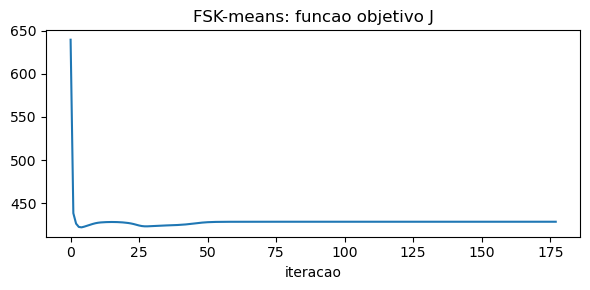

In [10]:
#BLOCO DE OBTENCAO DOS CENTROIDES FINAIS E PERTENCIMENTOS

#BOLEANO PARA VERIFICAR SE CONVERGIU OU NAO
convergencia = False
iteracao = 0
#CONTADOR DE ITERACOES
historico = []
#LISTA PARA ARMAZENAR OS RESULTADOS PARA ANALISE POSTERIOR

while not convergencia and iteracao < max_iter:
    #LOOP PARA CALCULAR AS DISTANCIAS E PERTENCIMENTOS
    distancias = calcular_distancias_algebrica(X_cluster, centroides)
    pertencimentos = calcular_pertencimentos_algebrica(distancias, m)
    centroides_novos = atualizar_centroides_algebrica(X_cluster, pertencimentos, m)
    delta = np.linalg.norm(centroides_novos - centroides)

    #min_cos = min_cosine_centroides(centroides_novos)
    #ent = entropia_fuzzy(pertencimentos)
    #ent_max = np.log(k)

    #if min_cos > 0.95 or ent > 0.95 * ent_max:
        #print(f"ALERTA colapso iter {iteracao}: min_cos={min_cos:.4f}, ent={ent:.3f}/{ent_max:.3f}")

    if delta < eps:
        convergencia = True

    #CALCULO DA FUNCAO OBJETIVO J - ACOMPANHAMENTO DA CONVERGENCIA
    jayM = np.sum((pertencimentos ** m) * (distancias ** 2))
    historico.append(jayM)
    print(
        f"Iter {iteracao}: delta={delta:.8f} | J={jayM:.4f}"
        #f"min_cos_cent={min_cos:.4f} | ent={ent:.3f}"
    )

    #ATUALIZACAO DOS CENTROIDES E DO CONTADOR DE ITERACOES
    centroides = centroides_novos
    iteracao += 1

plt.figure(figsize=(6, 3))
plt.plot(historico)
plt.title("FSK-means: funcao objetivo J")
plt.xlabel("iteracao")
plt.tight_layout()
plt.show()

In [11]:
# Comparacao: KMeans baseline vs FSK-means (executar APOS o treino acima)

km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster)
rotulos_km = km.labels_
cent_km = normalize(km.cluster_centers_, norm="l2", axis=1)
min_cos_km = (cent_km @ cent_km.T)[np.triu_indices(k, 1)].min()

rotulos_fsk = np.argmax(pertencimentos, axis=1)
min_cos_fsk = min_cosine_centroides(centroides)
ent = entropia_fuzzy(pertencimentos)
ent_max = np.log(k)

print("=== METRICAS ===")
print(f"SVD={SVD_COMPONENTS} | k={k} | m={m}")
print(f"KMeans  sil_cosine={silhouette_score(X_cluster, rotulos_km, metric='cosine'):.4f} | min_cos_cent={min_cos_km:.4f}")
print(f"FSK     sil_cosine={silhouette_score(X_cluster, rotulos_fsk, metric='cosine'):.4f} | min_cos_cent={min_cos_fsk:.4f}")
print(f"FSK entropia={ent:.3f}/{ent_max:.3f} ({ent/ent_max:.1%}) | std(mu)={pertencimentos.std(axis=1).mean():.4f}")
if min_cos_fsk > 0.95 or ent > 0.95 * ent_max:
    print("ALERTA: possivel colapso fuzzy")
else:
    print("FSK: pertencimentos nao uniformes (sem colapso)")

NameError: name 'min_cosine_centroides' is not defined

## 6.3 - OBTENCAO DO CLUSTER DOMINANTE E VISUALIZACAO DAS PROPORCOES DE PERTENCIMENTO

In [12]:
#BLOCO DE OBTENCAO DOS CLUSTERS, SALVANDO EM DICIONARIOS

rotulos = np.argmax(pertencimentos, axis=1)

df_clusters = pd.DataFrame({
    "id": ids,
    "cluster_dominante": rotulos
})

for c in range(pertencimentos.shape[1]):
    df_clusters[f"cluster_{c}"] = pertencimentos[:, c]

df_clusters


,id,cluster_dominante,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10,cluster_11
0,61468467,10,0.049695,0.050639,0.039883,0.075279,0.049729,0.038144,0.045880,0.038625,0.052154,0.056800,0.460862,0.042309
1,67361589,10,0.054886,0.047404,0.039798,0.060026,0.051623,0.039581,0.046021,0.037284,0.050776,0.057537,0.474714,0.040351
2,59084711,0,0.226194,0.087378,0.054706,0.060193,0.081243,0.061000,0.074269,0.049715,0.077911,0.107645,0.054827,0.064919
3,22676398,3,0.009925,0.014409,0.005417,0.900765,0.006193,0.005718,0.006647,0.005065,0.008406,0.011226,0.020010,0.006219
4,68785015,10,0.065132,0.060373,0.054868,0.075783,0.065581,0.053451,0.060451,0.052013,0.063150,0.069570,0.325564,0.054063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9357,5675990,2,0.012884,0.011557,0.841645,0.011319,0.017061,0.010189,0.027655,0.011803,0.014079,0.023778,0.008875,0.009155
9358,40301232,6,0.046906,0.034830,0.121825,0.021858,0.122386,0.027149,0.385438,0.040343,0.030214,0.117212,0.023034,0.028806
9359,48352825,2,0.001658,0.002194,0.980551,0.001218,0.001448,0.001499,0.002372,0.001435,0.002489,0.002660,0.001203,0.001272
9360,1935196,9,0.075877,0.065251,0.061253,0.072002,0.083603,0.039924,0.123168,0.104824,0.084423,0.208332,0.047716,0.033626


## 6.4 - VISUALIZAÇÃO PÓS-GRUPAMENTO

In [ ]:
# GRAFICO 3D POS CLUSTERIZACAO — pertencimentos fuzzy (soft)

rotulos = np.argmax(pertencimentos, axis=1)

fig_pos = plot_fuzzy_umap_3d(
    X_umap_3d,
    pertencimentos,
    threshold=0.05,
    ids=ids,
)
fig_pos.show()


## 7 - NOMEAÇÃO DOS CLUSTERS - ADICIONAR SEMANTICA

Após a convergência do algoritmo, foram selecionados os documentos mais próximos de cada centróide. Esses documentos representam os exemplos mais característicos de cada agrupamento e permitiram identificar manualmente o tema predominante de cada cluster. A partir dessa análise qualitativa, foram atribuídos rótulos descritivos aos grupos encontrados.

In [14]:
# 7 — INTERPRETAÇÃO SEMÂNTICA DOS CLUSTERS (proximidade ao centróide)
#
# Entradas do pipeline FSK-means (sem alterar o algoritmo):
#   X_cluster, centroides, rotulos, pertencimentos, ids, titulos
#
# =============================================================================
# LÓGICA MATEMÁTICA
# =============================================================================
# Vetores em X_cluster e centroides são L2-normalizados (||x||=||c||=1).
# Portanto:  cos(x_i, c_j) = x_i · c_j
#
# O centróide c_j é a média ponderada fuzzy dos documentos do cluster j,
# reprojetada na esfera. Representa a direção semântica média do grupo.
# Documentos com maior cosseno ao centróide próprio são os mais "típicos"
# do cluster → base para interpretação e nomeação manual do tema.
# =============================================================================

TOP_N = 10
N_TITULOS_RESUMO = 5

if "titulos" not in globals():
    titulos = [doc.get("titulo", doc.get("name", "")) for doc in amostra_completa]

X_arr = np.asarray(X_cluster, dtype=float)
cent = np.asarray(centroides, dtype=float)
cent = cent / np.linalg.norm(cent, axis=1, keepdims=True)

rotulos_arr = np.asarray(rotulos, dtype=int)
P = np.asarray(pertencimentos, dtype=float)
k = cent.shape[0]
ids_arr = np.asarray(ids)
titulos_arr = np.asarray(titulos, dtype=object)

# (n_docs, k) — similaridade cosseno vetorizada: sim[i,j] = cos(x_i, c_j)
sim_matrix = X_arr @ cent.T

rows = []
for j in range(k):
    mask = rotulos_arr == j
    n_cluster = int(mask.sum())
    if n_cluster == 0:
        continue

    idx_cluster = np.where(mask)[0]
    sims = sim_matrix[idx_cluster, j]
    mu = P[idx_cluster, j]

    order = np.argsort(-sims)
    top_doc_idx = idx_cluster[order[:TOP_N]]
    top_sims = sims[order[:TOP_N]]
    top_mu = mu[order[:TOP_N]]

    for rank, (doc_i, sim_val, mu_val) in enumerate(
        zip(top_doc_idx, top_sims, top_mu), start=1
    ):
        rows.append({
            "cluster": j,
            "n_documentos": n_cluster,
            "rank": rank,
            "id": ids_arr[doc_i],
            "titulo": titulos_arr[doc_i],
            "similaridade": float(sim_val),
            "pertencimento": float(mu_val),
        })

df_top10_clusters = pd.DataFrame(rows, columns=[
    "cluster", "n_documentos", "rank", "id", "titulo",
    "similaridade", "pertencimento",
])

resumo_rows = []
for j in range(k):
    sub = df_top10_clusters[df_top10_clusters["cluster"] == j].sort_values("rank")
    n_cluster = int((rotulos_arr == j).sum())
    row = {"cluster": j, "n_documentos": n_cluster}
    for i in range(1, N_TITULOS_RESUMO + 1):
        row[f"titulo_{i}"] = sub.iloc[i - 1]["titulo"] if len(sub) >= i else ""
    resumo_rows.append(row)

df_resumo_clusters = pd.DataFrame(resumo_rows)

print("=== Top 10 documentos representativos por cluster ===")
display(df_top10_clusters.style.format({
    "similaridade": "{:.3f}",
    "pertencimento": "{:.3f}",
}))

print("\n=== Resumo rápido (5 títulos centrais por cluster) ===")
display(df_resumo_clusters)

from IPython.display import Markdown

for j in range(k):
    sub = df_top10_clusters[df_top10_clusters["cluster"] == j].sort_values("rank")
    if sub.empty:
        continue
    n_cluster = int(sub["n_documentos"].iloc[0])
    display(Markdown(
        f"### Cluster **{j}** — {n_cluster} docs | "
        f"top {TOP_N} mais centrais (maior cos(x, c))"
    ))
    display(sub[["rank", "id", "titulo", "similaridade", "pertencimento"]].style.format({
        "similaridade": "{:.4f}",
        "pertencimento": "{:.4f}",
    }))


=== Top 10 documentos representativos por cluster ===


,cluster,n_documentos,rank,id,titulo,similaridade,pertencimento
0,0,1344,1,71460614,"History of Ajax, Ontario",0.919,0.920
1,0,1344,2,1504253,Mizil,0.899,0.863
2,0,1344,3,1909709,Menstrie,0.898,0.889
3,0,1344,4,1203585,"Taradale, New Zealand",0.892,0.873
4,0,1344,5,315419,Biggleswade,0.888,0.875
5,0,1344,6,854391,"Belgrave, Leicester",0.884,0.855
6,0,1344,7,126352,"Fleischmanns, New York",0.883,0.817
7,0,1344,8,72119,Salisbury,0.883,0.826
8,0,1344,9,2967779,Newburn,0.881,0.854
9,0,1344,10,1046206,"Yarralumla, Australian Capital Territory",0.879,0.842



=== Resumo rápido (5 títulos centrais por cluster) ===


,cluster,n_documentos,titulo_1,titulo_2,titulo_3,titulo_4,titulo_5
0,0,1344,"History of Ajax, Ontario",Mizil,Menstrie,"Taradale, New Zealand",Biggleswade
1,1,972,International Prototype of the Kilogram,Linkage (mechanical),Nixie tube,Java ConcurrentMap,Field-effect transistor
2,2,331,Adult Swim Yule Log,Redbelt,Veronica Guerin (film),The Man Without a Body,Darkest Night (film)
3,3,370,SS Dover Hill,USNS Sgt. Jack J. Pendleton,USS Wadsworth (DD-60),USS Cleveland (CL-55),USCGC Planetree
4,4,651,"Philip Wharton, 1st Duke of Wharton","Archibald Campbell, 9th Earl of Argyll",Nicholas Szécsényi,Gilbert Burnet,Richard Morgan (Tudor judge)
5,5,271,Oral cancer,Long QT syndrome,Fibrous ankylosis,Leber's hereditary optic neuropathy,Osteochondritis dissecans
6,6,1040,"Hussein, An Entertainment",Mom & Me & Mom,The Tale of the Pie and the Patty-Pan,A Portrait of the Artist as a Young Man,Jane Roberts
7,7,616,Lust for Life (Iggy Pop album),(Untitled) (The Byrds album),Friends and Lovers (Bernard Butler album),Astoria (Marianas Trench album),Garcia (1972 album)
8,8,1186,Contents of the United States diplomatic cable...,Political positions of Dianne Feinstein,Projects of the Caribbean Community,2019 shipping of humanitarian aid to Venezuela,Corruption in Italy
9,9,1658,William Lawson (co-operator),Eugene Rivers,John G. Bennett,Isaac Perrins,Homaro Cantu


### Cluster **0** — 1344 docs | top 10 mais centrais (maior cos(x, c))

...

,rank,id,titulo,similaridade,pertencimento
90,1,30654175,William Lawson (co-operator),0.8515,0.4239
91,2,7672698,Eugene Rivers,0.8374,0.5100
92,3,215298,John G. Bennett,0.8372,0.4087
93,4,31318372,Isaac Perrins,0.8369,0.3971
94,5,1731787,Homaro Cantu,0.8323,0.4421
95,6,44149920,Ebenezer Mackintosh,0.8214,0.3680
96,7,3309716,History of merit badges (Scouting America),0.8163,0.3575
97,8,3835326,George Julian Harney,0.8154,0.3113
98,9,48552707,Vanessa Williams and Miss America,0.8150,0.4274
99,10,39494606,Charlie Dunn,0.8149,0.4946


### Cluster **10** — 605 docs | top 10 mais centrais (maior cos(x, c))

,rank,id,titulo,similaridade,pertencimento
100,1,40653405,1981 Entumbane uprising,0.9452,0.9751
101,2,73805296,Second Battle of Szolnok,0.9426,0.9825
102,3,69688368,Zungeni Mountain skirmish,0.9419,0.9747
103,4,68218661,"134th Siege Battery, Royal Garrison Artillery",0.9390,0.9785
104,5,38378794,Battle of Bolshie Ozerki,0.9365,0.9745
105,6,75316324,Battle of Flondar,0.9350,0.9774
106,7,77821026,Assault on Majevica (1995),0.9329,0.9714
107,8,36717539,Pursuit to Haritan,0.9266,0.9694
108,9,46307507,Battle for Outpost Vegas,0.9260,0.9606
109,10,70788215,"111th (Bolton) Field Regiment, Royal Artillery",0.9230,0.9634


### Cluster **11** — 318 docs | top 10 mais centrais (maior cos(x, c))

,rank,id,titulo,similaridade,pertencimento
110,1,340167,Giant anteater,0.9867,0.9995
111,2,12516443,Amblysomus,0.9826,0.9990
112,3,12531091,Panamint chipmunk,0.9815,0.9989
113,4,1210385,Ruffed lemur,0.9752,0.9978
114,5,9034098,Waptia,0.9742,0.9970
115,6,29657,Salamander,0.9740,0.9976
116,7,12599560,Maltese skate,0.9731,0.9975
117,8,80393,Echidna,0.9729,0.9960
118,9,17236408,Silky sifaka,0.9714,0.9969
119,10,30472532,Moringa stenopetala,0.9705,0.9969
